# Heart Disease Prediction (Classification)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## LOAD DATASET

In [3]:
df=pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
# Checking Duplicates
df.duplicated().sum()

np.int64(723)

In [8]:
# There are 723 duplicate values present in the data, to remove them drop statement used
df = df.drop_duplicates()
df.reset_index(drop=True, inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='target'>

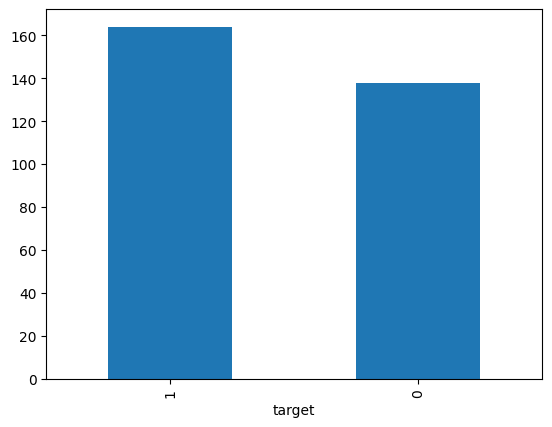

In [10]:
df['target'].value_counts().plot(kind='bar')

In [11]:
# Checking NULL values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

#### No missing value found

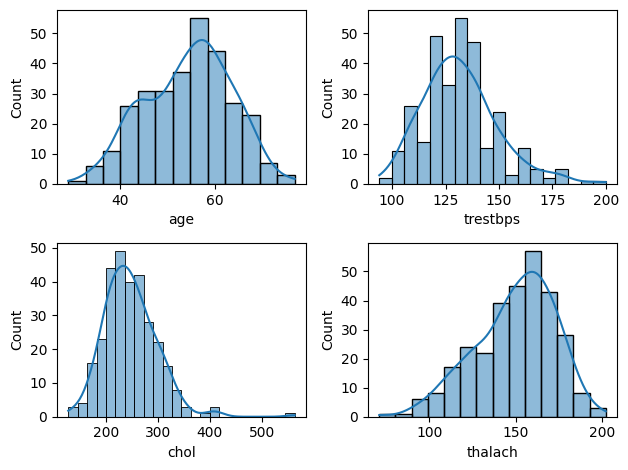

In [12]:
# Creating function plotting for subplot
def plotting(var,num):
   plt.subplot(2,2,num)
   sns.histplot(df[var],kde= True)
plotting('age',1)
plotting('trestbps',2)
plotting('chol',3)
plotting('thalach',4)
plt.tight_layout()

<Axes: xlabel='sex', ylabel='count'>

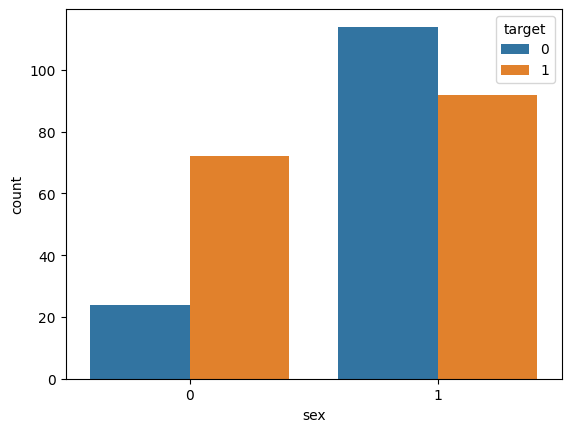

In [13]:
# Creating count plot
sns.countplot(x=df['sex'],hue=df['target'])

### Males affected more heart disease as compared to Females.

<Axes: xlabel='target', ylabel='chol'>

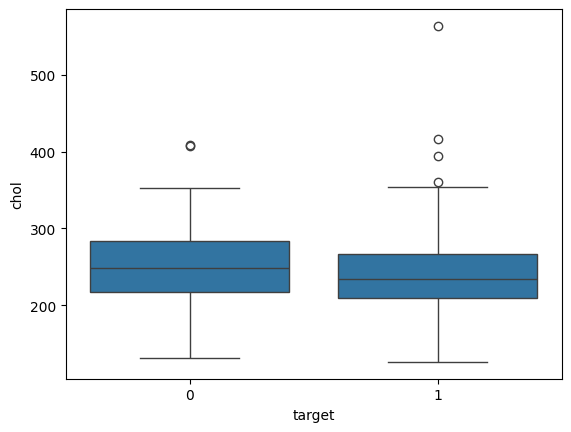

In [14]:
sns.boxplot(x='target',y='chol',data=df)

<Axes: xlabel='target', ylabel='age'>

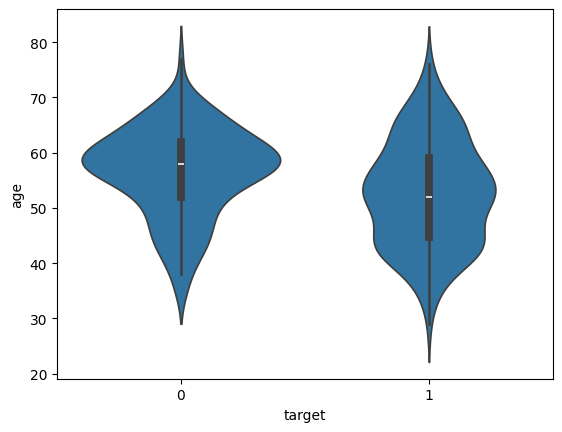

In [15]:
sns.violinplot(x='target',y='age',data=df)

### Heart disease patients are moslty from age group 40-60

<Axes: >

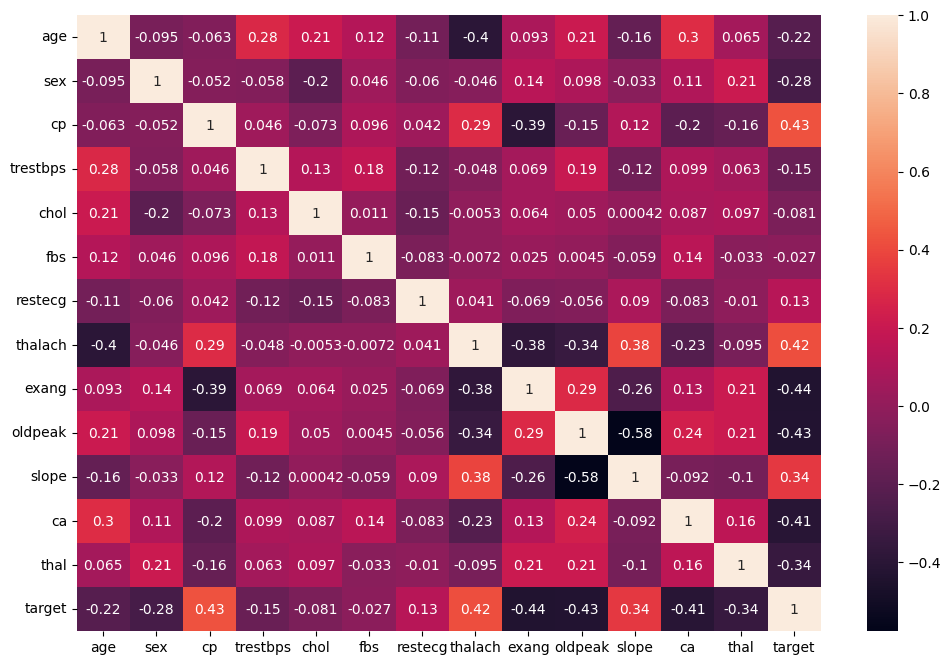

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [17]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### One hot encoding on nominal columns

In [18]:
df_encoded=pd.get_dummies(df, columns =['cp','restecg','slope','thal'], drop_first = True)

In [19]:
df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,0,False,False,False,True,False,False,True,False,False,True
1,53,1,140,203,1,155,1,3.1,0,0,False,False,False,False,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,0,False,False,False,True,False,False,False,False,False,True
3,61,1,148,203,0,161,0,0.0,1,0,False,False,False,True,False,False,True,False,False,True
4,62,0,138,294,1,106,0,1.9,3,0,False,False,False,True,False,True,False,False,True,False


In [20]:
# Only convert the one-hot encoded boolean columns to int, not the whole df
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.dtypes

age            int64
sex            int64
trestbps       int64
chol           int64
fbs            int64
thalach        int64
exang          int64
oldpeak      float64
ca             int64
target         int64
cp_1           int64
cp_2           int64
cp_3           int64
restecg_1      int64
restecg_2      int64
slope_1        int64
slope_2        int64
thal_1         int64
thal_2         int64
thal_3         int64
dtype: object

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, classification_report

In [22]:
X=df_encoded.drop('target',axis=1)
y=df_encoded['target']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train 3 Different Models

In [28]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(max_depth = None,random_state=42),
    "KNN": KNeighborsClassifier()
}

In [34]:
results=[]
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4)
    })
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8197,
  'Precision': 0.8235,
  'Recall': 0.8485,
  'F1 Score': 0.8358},
 {'Model': 'Random Forest',
  'Accuracy': 0.8033,
  'Precision': 0.8387,
  'Recall': 0.7879,
  'F1 Score': 0.8125},
 {'Model': 'KNN',
  'Accuracy': 0.7869,
  'Precision': 0.8125,
  'Recall': 0.7879,
  'F1 Score': 0.8}]

In [38]:
results_df = pd.DataFrame(results) 

Best model: Logistic Regression


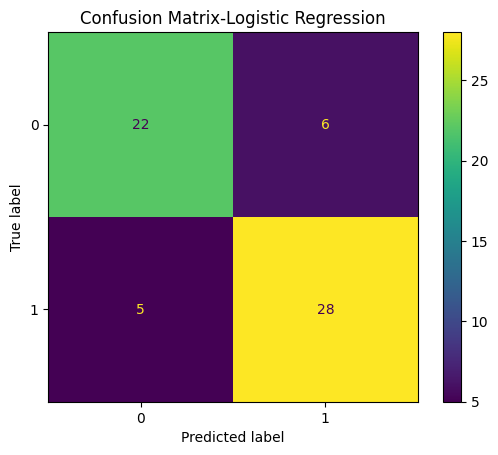

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
best=results_df.sort_values('F1 Score',ascending=False).iloc[0]['Model']
print("Best model:", best)
best_model=models[best]

pred = best_model.predict(X_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm).plot()
plt.title(f'Confusion Matrix-{best}')
plt.show()

### Conclusion
**Logistic Regression** came out as the best model, with the **highest F1 Score (0.8358)** and **best recall (0.8485)**, meaning it caught the most real heart disease cases correctly, the most important thing in a medical prediction task, since missing a sick patient is worse than a false alarm. Random Forest and KNN scored slightly lower, especially on recall, so they missed more true cases. This happened because the dataset is small, clean, and mostly linear, so a simpler model like Logistic Regression generalized better instead of overfitting like the more complex models can. **Overall, the project shows that basic patient health data (age, cholesterol, blood pressure, etc.) can predict heart disease risk, with Logistic Regression giving the most reliable ~82% accurate predictions.**